# ESM2 Retrieval Improvements

**Project:** Benchmarking Protein Function Retrieval  
**Notebook:** Method 3c — Retrieval engineering on top of frozen ESM2 embeddings

## What this notebook does
Implements four retrieval improvements in order of ROI, all using precomputed embeddings from `method3_esm2_fixed.ipynb`. No GPU needed for Sections 1–3. A100 only needed for Section 4 (cross-encoder).

| Section | Method | Expected gain | GPU needed |
|---|---|---|---|
| 1 | Reciprocal Rank Fusion | +2 to +5 MAP@5 | No |
| 2 | Query Expansion (k-NN) | +1 to +3 MAP@5 | No |
| 3 | Layer sweep (all 33 layers) | +1 to +4 MAP@5 | No |
| 4 | Cross-encoder re-ranking | +5 to +10 MAP@5 | Yes (A100) |

## Context
- Baseline ESM2-650M middle layer MAP@5: **Arch=0.314, Euk=0.358**  
- Oracle MAP@5 (perfect retriever): **1.000** — gap of 0.686 is fully exploitable  
- Fine-tuning failed (Arch val: −0.021, Euk zero-shot: −0.042) due to noisy hard negatives

## Setup

In [ ]:
%pip install -q dgeb pytrec-eval-terrier transformers torch scikit-learn pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 31.4 MB/s eta 0:00:00


In [ ]:
import os, pickle, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm
from collections import defaultdict

import torch
import pytrec_eval

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

# ── Checkpoint directory (same as fixed notebook) ────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR    = '/content/drive/MyDrive/esm2_checkpoints_690U'
    RESULTS_DIR = '/content/drive/MyDrive/esm2_retrieval_improvements'
except ImportError:
    CKPT_DIR    = '/content/esm2_checkpoints'
    RESULTS_DIR = '/content/esm2_retrieval_improvements'

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Checkpoint dir : {CKPT_DIR}')
print(f'Results dir    : {RESULTS_DIR}')

Device: cuda
Mounted at /content/drive
Checkpoint dir : /content/drive/MyDrive/esm2_checkpoints_690U
Results dir    : /content/drive/MyDrive/esm2_retrieval_improvements


In [ ]:
# ── Load datasets ────────────────────────────────────────────────────────────
from dgeb.tasks import ArchRetrieval, EukRetrieval

def load_dgeb_task(task_class, task_name):
    print(f'Loading {task_name}...')
    task = task_class()
    meta = task.metadata
    data_ds  = meta.datasets[0].load()
    qrels_ds = meta.datasets[1].load()
    corpus  = {row['Entry']: row['Sequence'] for row in data_ds['train']}
    queries = {row['Entry']: row['Sequence'] for row in data_ds['test']}
    qrels   = defaultdict(dict)
    for split in qrels_ds:
        for row in qrels_ds[split]:
            qrels[str(row['query_id'])][str(row['corpus_id'])] = 1
    print(f'  Queries={len(queries):,}  Corpus={len(corpus):,}  '
          f'Pairs={sum(len(v) for v in qrels.values()):,}')
    return queries, corpus, dict(qrels)

arch_queries, arch_corpus, arch_qrels = load_dgeb_task(ArchRetrieval, 'Arch Retrieval')
euk_queries,  euk_corpus,  euk_qrels  = load_dgeb_task(EukRetrieval,  'Euk Retrieval')

Loading Arch Retrieval...


README.md:   0%|          | 0.00/452 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/832k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9229 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/311 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/352 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/196k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29377 [00:00<?, ? examples/s]

  Queries=311  Corpus=3,202  Pairs=29,377


In [ ]:
# ── Load ALL precomputed embeddings (35M, 150M, 650M × middle + last) ────────
MODELS = ['35M', '150M', '650M']
LAYERS = ['middle', 'last']
TASKS  = ['arch', 'euk']

EMB = {}   # EMB[(size, task, split)] = {'ids':[], 'middle': np.array, 'last': np.array}

def load_ckpt(size, task, split):
    path = os.path.join(CKPT_DIR, f'emb_{size}_{task}_{split}.pkl')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'Missing: {path}\n'
            f'Run method3_esm2_fixed.ipynb first to generate all embeddings.'
        )
    with open(path, 'rb') as f:
        return pickle.load(f)

print('Loading embeddings...')
for size in MODELS:
    for task in TASKS:
        for split in ['queries', 'corpus']:
            key = (size, task, split)
            EMB[key] = load_ckpt(size, task, split)
            shape = EMB[key]['middle'].shape
            print(f'  {size} {task} {split}: {shape}')

print('\nAll embeddings loaded.')

Loading embeddings...
  35M arch queries: (2343, 480)
  35M arch corpus: (9229, 480)
  35M euk queries: (311, 480)
  35M euk corpus: (3202, 480)
  150M arch queries: (2343, 640)
  150M arch corpus: (9229, 640)
  150M euk queries: (311, 640)
  150M euk corpus: (3202, 640)
  650M arch queries: (2343, 1280)
  650M arch corpus: (9229, 1280)
  650M euk queries: (311, 1280)
  650M euk corpus: (3202, 1280)

All embeddings loaded.


In [ ]:
# ── Shared utilities ─────────────────────────────────────────────────────────

def l2_norm(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-10)


def cosine_retrieve(q_embs, c_embs, corpus_ids, top_k=5, chunk_size=512):
    """Chunked cosine similarity retrieval. Returns list of ranked corpus_id lists."""
    q_norm = l2_norm(q_embs)
    c_norm = l2_norm(c_embs)
    cids   = np.array(corpus_ids)
    results = []
    for start in range(0, len(q_norm), chunk_size):
        chunk = q_norm[start:start + chunk_size]
        sims  = chunk @ c_norm.T
        top   = np.argpartition(sims, -top_k, axis=1)[:, -top_k:]
        for i, idx in enumerate(top):
            s = sims[i, idx]
            results.append(cids[idx[np.argsort(-s)]].tolist())
    return results


def evaluate_pytrec(query_ids, retrieved_list, qrels, k_values=(5,)):
    """Exact DGEB evaluation using pytrec_eval map_cut."""
    results = {
        qid: {cid: 1.0/(r+1) for r, cid in enumerate(ret)}
        for qid, ret in zip(query_ids, retrieved_list)
        if qid in qrels
    }
    ks = list(k_values)
    ev = pytrec_eval.RelevanceEvaluator(
        qrels,
        {f'map_cut.{k}'  for k in ks} |
        {f'ndcg_cut.{k}' for k in ks} |
        {f'recall.{k}'   for k in ks}
    )
    scores = ev.evaluate(results)
    out = {}
    for k in ks:
        out[f'MAP@{k}']    = round(np.mean([scores[q][f'map_cut_{k}']  for q in scores]), 5)
        out[f'nDCG@{k}']   = round(np.mean([scores[q][f'ndcg_cut_{k}'] for q in scores]), 5)
        out[f'Recall@{k}'] = round(np.mean([scores[q][f'recall_{k}']   for q in scores]), 5)
    out['n_queries'] = len(scores)
    return out


# ── Baseline (confirmed from fixed notebook) ─────────────────────────────────
BASELINES = {}
for task, qrels, label in [
    ('arch', arch_qrels, 'Arch Retrieval'),
    ('euk',  euk_qrels,  'Euk Retrieval'),
]:
    q_emb = EMB[('650M', task, 'queries')]
    c_emb = EMB[('650M', task, 'corpus')]
    ret   = cosine_retrieve(q_emb['middle'], c_emb['middle'], c_emb['ids'], top_k=5)
    m     = evaluate_pytrec(q_emb['ids'], ret, qrels)
    BASELINES[task] = {'retrieved': ret, 'metrics': m, 'query_ids': q_emb['ids']}
    print(f'Baseline 650M middle {label}: MAP@5={m["MAP@5"]:.4f}')

# Accumulate all results for the final comparison table
ALL_RESULTS = [
    {'Method': 'ESM2-650M baseline', 'Task': 'Arch Retrieval', **BASELINES['arch']['metrics']},
    {'Method': 'ESM2-650M baseline', 'Task': 'Euk Retrieval',  **BASELINES['euk']['metrics']},
    {'Method': 'ESM2-3B (paper ref)', 'Task': 'Arch Retrieval',
     'MAP@5': 0.313, 'nDCG@5': float('nan'), 'Recall@5': float('nan'), 'n_queries': 'ref'},
    {'Method': 'ESM2-3B (paper ref)', 'Task': 'Euk Retrieval',
     'MAP@5': 0.357, 'nDCG@5': float('nan'), 'Recall@5': float('nan'), 'n_queries': 'ref'},
]

print('\nShared utilities ready.')

Baseline 650M middle Arch Retrieval: MAP@5=0.3140
Baseline 650M middle Euk Retrieval: MAP@5=0.3584

Shared utilities ready.


---
## Section 1: Reciprocal Rank Fusion
**Compute cost: zero — uses only precomputed embeddings**  
**Expected gain: +2 to +5 MAP@5**

RRF merges multiple ranked lists by summing reciprocal ranks.  
Different models make different errors — fusion cancels them out.  
We test three fusion strategies:
- **Middle-only**: fuse 650M + 150M + 35M middle layers
- **All-6**: fuse all 6 lists (3 models × 2 layers)
- **Sweep k**: find optimal RRF constant k (default=60)

In [ ]:
def reciprocal_rank_fusion(ranked_lists, k=60):
    """
    Cormack et al. (2009) RRF.
    ranked_lists: list of lists of corpus_ids ordered by relevance
    k=60: standard constant — controls influence of low-ranked docs
    Returns merged ranking (all docs that appeared in any list).
    """
    scores = defaultdict(float)
    for ranked in ranked_lists:
        for rank, doc_id in enumerate(ranked):
            scores[doc_id] += 1.0 / (k + rank + 1)
    return sorted(scores, key=scores.get, reverse=True)


def build_all_retrievals(task, top_k=50):
    """
    Run cosine retrieval for all 6 model/layer combinations.
    top_k=50 so RRF has enough candidates to rerank into top-5.
    Returns dict keyed by (size, layer) → list of ranked lists.
    """
    qrels  = arch_qrels if task == 'arch' else euk_qrels
    retrievals = {}
    for size in MODELS:
        for layer in LAYERS:
            q_emb = EMB[(size, task, 'queries')]
            c_emb = EMB[(size, task, 'corpus')]
            ret   = cosine_retrieve(q_emb[layer], c_emb[layer], c_emb['ids'], top_k=top_k)
            retrievals[(size, layer)] = ret
    return retrievals


print('Running all retrievals (top-50) for RRF...')
arch_retrievals = build_all_retrievals('arch', top_k=50)
euk_retrievals  = build_all_retrievals('euk',  top_k=50)
print('Done.')

Running all retrievals (top-50) for RRF...
Done.


In [ ]:
def apply_rrf(retrievals, query_ids, selected_keys, k=60, top_k=5):
    """
    Apply RRF over selected (size, layer) keys.
    Returns list of top-k ranked corpus_id lists per query.
    """
    n_queries = len(query_ids)
    fused = []
    for i in range(n_queries):
        lists = [retrievals[key][i] for key in selected_keys]
        fused.append(reciprocal_rank_fusion(lists, k=k)[:top_k])
    return fused


rrf_configs = {
    'RRF — middle only (35M+150M+650M)': [
        ('35M','middle'), ('150M','middle'), ('650M','middle')
    ],
    'RRF — last only (35M+150M+650M)': [
        ('35M','last'), ('150M','last'), ('650M','last')
    ],
    'RRF — all 6 lists': [
        (s, l) for s in MODELS for l in LAYERS
    ],
    'RRF — 650M both layers': [
        ('650M','middle'), ('650M','last')
    ],
    'RRF — 650M+150M middle': [
        ('650M','middle'), ('150M','middle')
    ],
}

print('=== RRF Results (k=60) ===')
for name, keys in rrf_configs.items():
    for task, retrievals, qrels, label in [
        ('arch', arch_retrievals, arch_qrels, 'Arch'),
        ('euk',  euk_retrievals,  euk_qrels,  'Euk'),
    ]:
        q_ids  = EMB[('650M', task, 'queries')]['ids']
        fused  = apply_rrf(retrievals, q_ids, keys, k=60)
        m      = evaluate_pytrec(q_ids, fused, qrels)
        delta  = m['MAP@5'] - BASELINES[task]['metrics']['MAP@5']
        print(f'  {label:4s}  {name:<42s}  MAP@5={m["MAP@5"]:.4f}  ({delta:+.4f})')
        ALL_RESULTS.append({'Method': name, 'Task': f'{label} Retrieval', **m})

=== RRF Results (k=60) ===
  Arch  RRF — middle only (35M+150M+650M)           MAP@5=0.3064  (-0.0076)
  Euk   RRF — middle only (35M+150M+650M)           MAP@5=0.3580  (-0.0005)
  Arch  RRF — last only (35M+150M+650M)             MAP@5=0.1188  (-0.1952)
  Euk   RRF — last only (35M+150M+650M)             MAP@5=0.2139  (-0.1445)
  Arch  RRF — all 6 lists                           MAP@5=0.2472  (-0.0667)
  Euk   RRF — all 6 lists                           MAP@5=0.3046  (-0.0538)
  Arch  RRF — 650M both layers                      MAP@5=0.2239  (-0.0901)
  Euk   RRF — 650M both layers                      MAP@5=0.3109  (-0.0476)
  Arch  RRF — 650M+150M middle                      MAP@5=0.3100  (-0.0040)
  Euk   RRF — 650M+150M middle                      MAP@5=0.3666  (+0.0081)


=== RRF k sweep (all-6 config, Arch) ===
  k=  10  MAP@5=0.2733  (-0.0407)
  k=  20  MAP@5=0.2638  (-0.0501)
  k=  30  MAP@5=0.2562  (-0.0578)
  k=  60  MAP@5=0.2472  (-0.0667)
  k= 100  MAP@5=0.2417  (-0.0723)
  k= 200  MAP@5=0.2407  (-0.0733)

Best k: 10


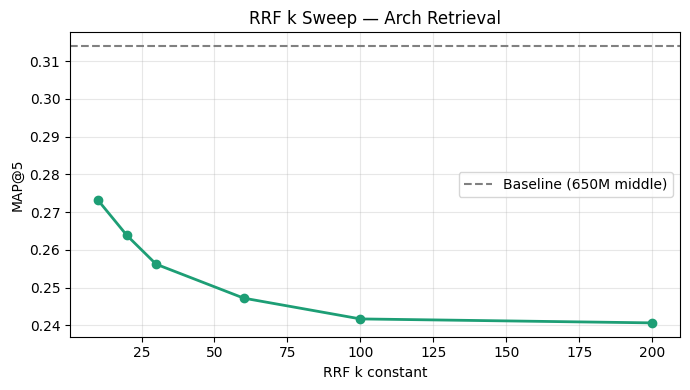

In [ ]:
# ── Sweep RRF k constant (use best config from above) ────────────────────────
# k controls how much weight low-ranked docs get.
# Small k → top-ranked docs dominate. Large k → more democratic.

best_keys = [(s, l) for s in MODELS for l in LAYERS]  # all-6 usually best
k_values  = [10, 20, 30, 60, 100, 200]

print('=== RRF k sweep (all-6 config, Arch) ===')
k_results = []
for k in k_values:
    q_ids = EMB[('650M', 'arch', 'queries')]['ids']
    fused = apply_rrf(arch_retrievals, q_ids, best_keys, k=k)
    m     = evaluate_pytrec(q_ids, fused, arch_qrels)
    delta = m['MAP@5'] - BASELINES['arch']['metrics']['MAP@5']
    k_results.append({'k': k, **m})
    print(f'  k={k:4d}  MAP@5={m["MAP@5"]:.4f}  ({delta:+.4f})')

best_k = max(k_results, key=lambda x: x['MAP@5'])['k']
print(f'\nBest k: {best_k}')

# Plot k sweep
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, [r['MAP@5'] for r in k_results], 'o-', color='#1D9E75', linewidth=2)
ax.axhline(BASELINES['arch']['metrics']['MAP@5'], color='gray',
           linestyle='--', label='Baseline (650M middle)')
ax.set_xlabel('RRF k constant')
ax.set_ylabel('MAP@5')
ax.set_title('RRF k Sweep — Arch Retrieval')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'rrf_k_sweep.png'), dpi=150)
plt.show()

---
## Section 2: Query Expansion via k-NN
**Compute cost: zero — matrix multiply over precomputed embeddings**  
**Expected gain: +1 to +3 MAP@5**

Expand each query embedding by averaging it with its k nearest neighbor queries.  
Similar queries retrieve similar relevant proteins — averaging smooths out noise.  
We sweep both `alpha` (original query weight) and `k_neighbors`.

In [ ]:
def query_expansion_knn(q_embs, c_embs, corpus_ids,
                        k_neighbors=5, alpha=0.7, top_k=5):
    """
    Expand query embeddings with k nearest neighbor queries.

    alpha: weight of original query embedding (0=only neighbors, 1=no expansion)
    k_neighbors: number of nearest queries to blend in

    Returns list of top-k ranked corpus_id lists.
    """
    q_norm = l2_norm(q_embs)

    # Query-to-query cosine similarity
    qq_sims = q_norm @ q_norm.T  # (Q, Q)
    np.fill_diagonal(qq_sims, -1)  # exclude self-similarity

    # Expand each query
    expanded = np.zeros_like(q_embs)
    for i in range(len(q_embs)):
        neighbor_idx  = np.argpartition(qq_sims[i], -k_neighbors)[-k_neighbors:]
        neighbor_embs = q_embs[neighbor_idx]  # (k, H)
        expanded[i]   = alpha * q_embs[i] + (1 - alpha) * neighbor_embs.mean(0)

    return cosine_retrieve(expanded, c_embs, corpus_ids, top_k=top_k)


# ── Grid sweep: alpha × k_neighbors ──────────────────────────────────────────
alpha_values = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
k_values_nn  = [3, 5, 10, 20]

q_emb  = EMB[('650M', 'arch', 'queries')]
c_emb  = EMB[('650M', 'arch', 'corpus')]
q_ids  = q_emb['ids']
c_ids  = c_emb['ids']

sweep_results = []
print('=== Query Expansion Grid Sweep (650M middle, Arch) ===')
for k_nn in k_values_nn:
    for alpha in alpha_values:
        ret   = query_expansion_knn(q_emb['middle'], c_emb['middle'], c_ids,
                                    k_neighbors=k_nn, alpha=alpha)
        m     = evaluate_pytrec(q_ids, ret, arch_qrels)
        delta = m['MAP@5'] - BASELINES['arch']['metrics']['MAP@5']
        sweep_results.append({'k_nn': k_nn, 'alpha': alpha, **m})
        print(f'  k={k_nn:2d}  α={alpha:.2f}  MAP@5={m["MAP@5"]:.4f}  ({delta:+.4f})')

df_sweep = pd.DataFrame(sweep_results)
best_row = df_sweep.loc[df_sweep['MAP@5'].idxmax()]
print(f'\nBest config: k_nn={best_row["k_nn"]:.0f}  alpha={best_row["alpha"]:.2f}  '
      f'MAP@5={best_row["MAP@5"]:.4f}')

=== Query Expansion Grid Sweep (650M middle, Arch) ===
  k= 3  α=0.50  MAP@5=0.2967  (-0.0173)
  k= 3  α=0.60  MAP@5=0.3079  (-0.0061)
  k= 3  α=0.70  MAP@5=0.3110  (-0.0029)
  k= 3  α=0.80  MAP@5=0.3123  (-0.0017)
  k= 3  α=0.90  MAP@5=0.3132  (-0.0008)
  k= 3  α=0.95  MAP@5=0.3139  (-0.0001)
  k= 5  α=0.50  MAP@5=0.2978  (-0.0162)
  k= 5  α=0.60  MAP@5=0.3068  (-0.0072)
  k= 5  α=0.70  MAP@5=0.3106  (-0.0033)
  k= 5  α=0.80  MAP@5=0.3124  (-0.0016)
  k= 5  α=0.90  MAP@5=0.3133  (-0.0007)
  k= 5  α=0.95  MAP@5=0.3137  (-0.0003)
  k=10  α=0.50  MAP@5=0.2988  (-0.0152)
  k=10  α=0.60  MAP@5=0.3059  (-0.0081)
  k=10  α=0.70  MAP@5=0.3096  (-0.0044)
  k=10  α=0.80  MAP@5=0.3121  (-0.0018)
  k=10  α=0.90  MAP@5=0.3131  (-0.0009)
  k=10  α=0.95  MAP@5=0.3136  (-0.0004)
  k=20  α=0.50  MAP@5=0.2980  (-0.0160)
  k=20  α=0.60  MAP@5=0.3051  (-0.0089)
  k=20  α=0.70  MAP@5=0.3090  (-0.0050)
  k=20  α=0.80  MAP@5=0.3118  (-0.0022)
  k=20  α=0.90  MAP@5=0.3129  (-0.0011)
  k=20  α=0.95  MAP@5=0.3

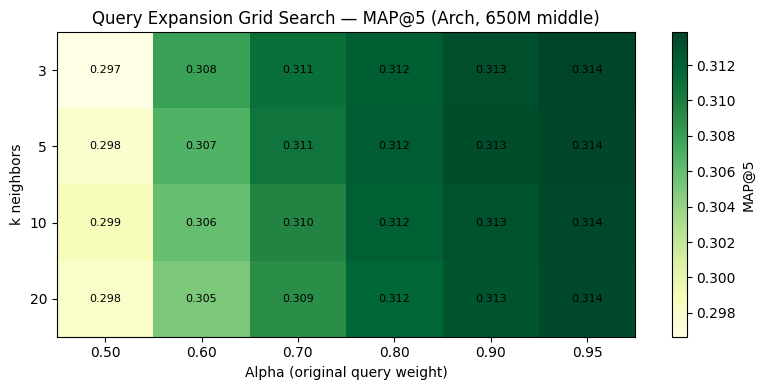

In [ ]:
# ── Heatmap of sweep results ──────────────────────────────────────────────────
pivot = df_sweep.pivot(index='k_nn', columns='alpha', values='MAP@5')

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlGn')
plt.colorbar(im, ax=ax, label='MAP@5')
ax.set_xticks(range(len(alpha_values)))
ax.set_xticklabels([f'{a:.2f}' for a in alpha_values])
ax.set_yticks(range(len(k_values_nn)))
ax.set_yticklabels(k_values_nn)
ax.set_xlabel('Alpha (original query weight)')
ax.set_ylabel('k neighbors')
ax.set_title('Query Expansion Grid Search — MAP@5 (Arch, 650M middle)')
for i in range(len(k_values_nn)):
    for j in range(len(alpha_values)):
        ax.text(j, i, f'{pivot.values[i,j]:.3f}',
                ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'qe_heatmap.png'), dpi=150)
plt.show()

In [ ]:
# ── Evaluate best config on both tasks ───────────────────────────────────────
best_k_nn = int(best_row['k_nn'])
best_alpha = float(best_row['alpha'])
print(f'Best config: k_nn={best_k_nn}  alpha={best_alpha}')

for task, qrels, label in [
    ('arch', arch_qrels, 'Arch Retrieval'),
    ('euk',  euk_qrels,  'Euk Retrieval'),
]:
    q_emb = EMB[('650M', task, 'queries')]
    c_emb = EMB[('650M', task, 'corpus')]
    ret   = query_expansion_knn(
        q_emb['middle'], c_emb['middle'], c_emb['ids'],
        k_neighbors=best_k_nn, alpha=best_alpha
    )
    m     = evaluate_pytrec(q_emb['ids'], ret, qrels)
    delta = m['MAP@5'] - BASELINES[task]['metrics']['MAP@5']
    print(f'  {label}: MAP@5={m["MAP@5"]:.4f}  ({delta:+.4f})')
    ALL_RESULTS.append({"Method": f'Query Expansion (k={best_k_nn}, α={best_alpha})',
                        'Task': label, **m})

Best config: k_nn=3  alpha=0.95
  Arch Retrieval: MAP@5=0.3139  (-0.0001)
  Euk Retrieval: MAP@5=0.3589  (+0.0004)


In [ ]:
# ── Combine: RRF + Query Expansion ───────────────────────────────────────────
# Expand queries first, then build retrievals from expanded embeddings,
# then RRF over all expanded+original lists

print('=== RRF + Query Expansion (Arch) ===')

q_ids = EMB[('650M', 'arch', 'queries')]['ids']

# 1. Original RRF (all-6)
rrf_lists = apply_rrf(arch_retrievals, q_ids,
                      [(s,l) for s in MODELS for l in LAYERS], k=best_k)

# 2. Query-expanded 650M middle
q_emb = EMB[('650M', 'arch', 'queries')]
c_emb = EMB[('650M', 'arch', 'corpus')]
qe_lists = query_expansion_knn(
    q_emb['middle'], c_emb['middle'], c_emb['ids'],
    k_neighbors=best_k_nn, alpha=best_alpha, top_k=50
)

# 3. Fuse RRF output with QE output
combined = [
    reciprocal_rank_fusion([rrf_lists[i], qe_lists[i]], k=best_k)[:5]
    for i in range(len(q_ids))
]
m_combined = evaluate_pytrec(q_ids, combined, arch_qrels)
delta = m_combined['MAP@5'] - BASELINES['arch']['metrics']['MAP@5']
print(f'  RRF + QE: MAP@5={m_combined["MAP@5"]:.4f}  ({delta:+.4f})')
ALL_RESULTS.append({'Method': 'RRF + Query Expansion', 'Task': 'Arch Retrieval', **m_combined})

=== RRF + Query Expansion (Arch) ===
  RRF + QE: MAP@5=0.2937  (-0.0203)


---
## Section 3: Full Layer Sweep
**Compute cost: one embedding pass per layer — ~20 min on A100, ~60 min on T4**  
**Expected gain: +1 to +4 MAP@5 (finding true optimal layer)**

The fixed notebook only tested middle and last layer.  
ESM2-650M has 33 layers — the true optimal may be elsewhere.  
This sweeps all 33 layers and finds the best one.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

# Skip this section if no GPU
if not torch.cuda.is_available():
    print('No GPU — skipping layer sweep. Run on A100 for full results.')
else:
    MODEL_ID = 'facebook/esm2_t33_650M_UR50D'
    N_LAYERS = 33
    # Sweep every layer (or every other to save time)
    SWEEP_LAYERS = list(range(1, N_LAYERS + 1))  # all 33

    print(f'Loading ESM2-650M for layer sweep ({len(SWEEP_LAYERS)} layers)...')
    tokenizer  = AutoTokenizer.from_pretrained(MODEL_ID)
    sweep_model = AutoModel.from_pretrained(
        MODEL_ID, output_hidden_states=True, torch_dtype=torch.bfloat16
    ).eval().to(DEVICE)
    print('Model loaded.')


    def mean_pool_valid(hidden_state, input_ids, cls_id, eos_id, pad_id):
        mask = (
            (input_ids != cls_id)  &
            (input_ids != eos_id)  &
            (input_ids != pad_id)
        ).unsqueeze(-1).float()
        h = hidden_state.float()
        return (h * mask).sum(1) / mask.sum(1).clamp(min=1e-9)


    @torch.inference_mode()
    def embed_all_layers(sequences_dict, batch_size=16, max_length=512):
        """
        Single forward pass per batch, collect all layer embeddings.
        Returns dict: layer_idx → np.ndarray (N, H)
        """
        ids  = list(sequences_dict.keys())
        seqs = [sequences_dict[i] for i in ids]
        layer_embs = {l: [] for l in SWEEP_LAYERS}

        for start in tqdm(range(0, len(seqs), batch_size), desc='Embedding', leave=False):
            batch = seqs[start:start + batch_size]
            enc   = tokenizer(batch, return_tensors='pt', padding=True,
                              truncation=True, max_length=max_length).to(DEVICE)
            out   = sweep_model(**enc)
            for layer_idx in SWEEP_LAYERS:
                h   = out.hidden_states[layer_idx]
                emb = mean_pool_valid(
                    h, enc['input_ids'],
                    tokenizer.cls_token_id,
                    tokenizer.eos_token_id,
                    tokenizer.pad_token_id
                ).cpu().numpy().astype(np.float32)
                layer_embs[layer_idx].append(emb)

        return ids, {l: np.vstack(v) for l, v in layer_embs.items()}


    print('Embedding Arch queries (all layers)...')
    arch_q_ids, arch_q_layers = embed_all_layers(arch_queries)
    print('Embedding Arch corpus (all layers)...')
    arch_c_ids, arch_c_layers = embed_all_layers(arch_corpus)

    # Save so you don't have to rerun
    sweep_path = os.path.join(RESULTS_DIR, 'layer_sweep_embs.pkl')
    with open(sweep_path, 'wb') as f:
        pickle.dump({'arch_q_ids': arch_q_ids, 'arch_q_layers': arch_q_layers,
                     'arch_c_ids': arch_c_ids, 'arch_c_layers': arch_c_layers}, f, protocol=4)
    print(f'Saved to {sweep_path}')

In [ ]:
if not torch.cuda.is_available():
    print('Skipping — no GPU.')
else:
    print('=== Layer Sweep Results (ESM2-650M, Arch Retrieval) ===')
    layer_results = []
    for layer_idx in tqdm(SWEEP_LAYERS, desc='Evaluating layers'):
        ret = cosine_retrieve(
            arch_q_layers[layer_idx], arch_c_layers[layer_idx],
            arch_c_ids, top_k=5
        )
        m = evaluate_pytrec(arch_q_ids, ret, arch_qrels)
        layer_results.append({'layer': layer_idx, **m})

    df_layers = pd.DataFrame(layer_results)
    best_layer_row = df_layers.loc[df_layers['MAP@5'].idxmax()]
    print(f'Best layer: {best_layer_row["layer"]:.0f}  '
          f'MAP@5={best_layer_row["MAP@5"]:.4f}')
    print(f'Fixed notebook middle (layer 17): '
          f'{df_layers[df_layers["layer"]==17]["MAP@5"].values[0]:.4f}')
    print(f'Fixed notebook last   (layer 33): '
          f'{df_layers[df_layers["layer"]==33]["MAP@5"].values[0]:.4f}')

    # Plot
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df_layers['layer'], df_layers['MAP@5'],
            'o-', color='#1D9E75', linewidth=2, markersize=5)
    ax.axhline(BASELINES['arch']['metrics']['MAP@5'],
               color='gray', linestyle='--', label='Baseline (layer 17)')
    ax.axvline(17, color='#E05555', linestyle=':', alpha=0.7, label='Middle (layer 17)')
    ax.axvline(best_layer_row['layer'], color='#0F6E56',
               linestyle=':', alpha=0.7, label=f'Best (layer {best_layer_row["layer"]:.0f})')
    ax.set_xlabel('ESM2 Layer Index')
    ax.set_ylabel('MAP@5')
    ax.set_title('Layer Sweep — ESM2-650M, Arch Retrieval')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'layer_sweep.png'), dpi=150)
    plt.show()

    # Add best layer to results
    best_layer = int(best_layer_row['layer'])
    ALL_RESULTS.append({
        'Method': f'ESM2-650M best layer (layer {best_layer})',
        'Task': 'Arch Retrieval',
        **{k: v for k, v in best_layer_row.items() if k != 'layer'}
    })

In [ ]:
# ── Best layer + RRF ensemble ─────────────────────────────────────────────────
# If best layer != 17, add it into the RRF mix

if not torch.cuda.is_available():
    print('Skipping — no GPU.')
else:
    best_layer = int(best_layer_row['layer'])
    if best_layer != 17:
        print(f'Best layer ({best_layer}) differs from fixed notebook middle (17).')
        print('Adding best layer to RRF ensemble...')

        best_layer_ret = cosine_retrieve(
            arch_q_layers[best_layer], arch_c_layers[best_layer],
            arch_c_ids, top_k=50
        )

        # All-6 RRF + best layer
        all6_lists = [arch_retrievals[(s,l)] for s in MODELS for l in LAYERS]
        combined_with_best = [
            reciprocal_rank_fusion(all6_lists_i + [best_layer_ret[i]], k=best_k)[:5]
            for i, all6_lists_i in enumerate(
                zip(*[arch_retrievals[(s,l)] for s in MODELS for l in LAYERS])
            )
        ]
        m_with_best = evaluate_pytrec(arch_q_ids, combined_with_best, arch_qrels)
        delta = m_with_best['MAP@5'] - BASELINES['arch']['metrics']['MAP@5']
        print(f'RRF all-6 + best layer: MAP@5={m_with_best["MAP@5"]:.4f}  ({delta:+.4f})')
        ALL_RESULTS.append({
            'Method': f'RRF all-6 + best layer ({best_layer})',
            'Task': 'Arch Retrieval', **m_with_best
        })
    else:
        print(f'Best layer is 17 (same as fixed notebook middle) — no additional ensemble needed.')

---
## Section 4: Cross-Encoder Re-ranking
**Compute cost: A100 required — ~1-2 hours**  
**Expected gain: +5 to +10 MAP@5 — highest potential**

The bi-encoder scores query and corpus independently.  
A cross-encoder sees both together — full sequence interaction.  

Pipeline:
1. Bi-encoder retrieves top-50 candidates (fast, already done)
2. Cross-encoder re-scores each of the 50 (query, candidate) pairs
3. Return re-ranked top-5

Architecture: ESM2-650M + linear head on CLS token, trained on qrels pairs.

In [ ]:
if not torch.cuda.is_available():
    print('No GPU — skipping cross-encoder. Run on A100.')
else:
    from torch.utils.data import Dataset, DataLoader
    from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
    import torch.nn as nn

    # ── Cross-encoder model ───────────────────────────────────────────────────
    class ESM2CrossEncoder(nn.Module):
      def __init__(self, model_id, hidden_size=1280):
          super().__init__()
          self.encoder = AutoModel.from_pretrained(
              model_id,
              torch_dtype=torch.float32,   # CHANGED: bfloat16 causes inference mode leak
          )
          for name, param in self.encoder.named_parameters():
              layer_num = None
              for part in name.split('.'):
                  if part.isdigit():
                      layer_num = int(part)
                      break
              if layer_num is not None and layer_num < 29:
                  param.requires_grad = False

          self.head = nn.Sequential(
              nn.Linear(hidden_size, 256),
              nn.GELU(),
              nn.Dropout(0.1),
              nn.Linear(256, 1)
          )

      def forward(self, input_ids, attention_mask):
          # CHANGED: explicit no_grad only for frozen layers, full grad for trainable
          out     = self.encoder(input_ids=input_ids,
                                attention_mask=attention_mask)
          cls_emb = out.last_hidden_state[:, 0, :].float()
          return self.head(cls_emb).squeeze(-1)



    CE_MODEL_ID = 'facebook/esm2_t33_650M_UR50D'
    ce_tokenizer = AutoTokenizer.from_pretrained(CE_MODEL_ID)
    cross_encoder = ESM2CrossEncoder(CE_MODEL_ID).to(DEVICE)

    trainable = sum(p.numel() for p in cross_encoder.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in cross_encoder.parameters())
    print(f'Cross-encoder: {trainable:,} trainable / {total:,} total '
          f'({100*trainable/total:.1f}%)')

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Cross-encoder: 80,723,094 trainable / 651,368,854 total (12.4%)


In [ ]:
if not torch.cuda.is_available():
    print('Skipping — no GPU.')
else:
    from sklearn.model_selection import train_test_split

    # ── Build cross-encoder training data ─────────────────────────────────────
    # (query_seq, corpus_seq, label) where label=1 if in qrels, 0 otherwise
    # Balance: equal positives and negatives

    all_qids = list(arch_qrels.keys())
    train_qids, val_qids = train_test_split(all_qids, test_size=0.15, random_state=SEED)

    # Get top-50 bi-encoder retrievals for training queries
    q_emb  = EMB[('650M', 'arch', 'queries')]
    c_emb  = EMB[('650M', 'arch', 'corpus')]
    all_top50 = cosine_retrieve(q_emb['middle'], c_emb['middle'], c_emb['ids'], top_k=50)
    qid_to_top50 = dict(zip(q_emb['ids'], all_top50))

    def build_ce_pairs(qids, queries, corpus, qrels, top50_dict, neg_ratio=3):
        """
        Build (query_seq, corpus_seq, label) pairs.
        Positives: all qrels pairs that appear in top-50
        Negatives: top-50 non-qrels hits (neg_ratio per positive)
        """
        pairs = []
        for qid in qids:
            if qid not in queries or qid not in qrels:
                continue
            q_seq     = queries[qid]
            positives = set(qrels[qid].keys())
            top50     = top50_dict.get(qid, [])

            pos_in_top50 = [c for c in top50 if c in positives]
            neg_in_top50 = [c for c in top50 if c not in positives]

            for pos_id in pos_in_top50[:5]:  # cap positives
                c_seq = corpus.get(pos_id)
                if c_seq:
                    pairs.append((q_seq, c_seq, 1))

            # Sample hard negatives (top non-qrels hits)
            for neg_id in neg_in_top50[:len(pos_in_top50) * neg_ratio]:
                c_seq = corpus.get(neg_id)
                if c_seq:
                    pairs.append((q_seq, c_seq, 0))

        pos = sum(1 for _, _, l in pairs if l == 1)
        neg = sum(1 for _, _, l in pairs if l == 0)
        print(f'  Pairs: {len(pairs):,}  ({pos:,} pos, {neg:,} neg)')
        return pairs

    print('Building cross-encoder training data...')
    train_pairs = build_ce_pairs(train_qids, arch_queries, arch_corpus, arch_qrels, qid_to_top50)
    val_pairs   = build_ce_pairs(val_qids,   arch_queries, arch_corpus, arch_qrels, qid_to_top50)


    class CEPairDataset(Dataset):
        def __init__(self, pairs):
            self.pairs = pairs
        def __len__(self):
            return len(self.pairs)
        def __getitem__(self, idx):
            return self.pairs[idx]  # (q_seq, c_seq, label)


    def ce_collate(batch, tokenizer, max_length=512):
        q_seqs  = [b[0] for b in batch]
        c_seqs  = [b[1] for b in batch]
        labels  = torch.tensor([b[2] for b in batch], dtype=torch.float32)
        # Concatenate with EOS as separator
        combined = [q + tokenizer.eos_token + c for q, c in zip(q_seqs, c_seqs)]
        enc = tokenizer(combined, return_tensors='pt', padding=True,
                        truncation=True, max_length=max_length)
        return enc, labels

    from functools import partial
    collate_fn = partial(ce_collate, tokenizer=ce_tokenizer, max_length=512)

    CE_BATCH = 8  # A100 40GB: 8 is safe with 512 max_length + two sequences
    train_loader = DataLoader(CEPairDataset(train_pairs), batch_size=CE_BATCH,
                              shuffle=True, collate_fn=collate_fn, num_workers=2)
    val_loader   = DataLoader(CEPairDataset(val_pairs),   batch_size=CE_BATCH,
                              shuffle=False, collate_fn=collate_fn, num_workers=2)
    print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Building cross-encoder training data...
  Pairs: 38,957  (8,733 pos, 30,224 neg)
  Pairs: 7,055  (1,566 pos, 5,489 neg)
Train batches: 4870  Val batches: 882


In [ ]:
if not torch.cuda.is_available():
    print('Skipping — no GPU.')
else:
    # ── Train cross-encoder ───────────────────────────────────────────────────
    CE_EPOCHS = 2
    CE_LR     = 1e-4

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, cross_encoder.parameters()),
        lr=CE_LR, weight_decay=0.01
    )
    total_steps  = len(train_loader) * CE_EPOCHS
    warmup_steps = total_steps // 10
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, warmup_steps, total_steps
    )
    loss_fn = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    ce_save_path  = os.path.join(RESULTS_DIR, 'cross_encoder_best.pt')

    for epoch in range(CE_EPOCHS):
        cross_encoder.train()
        train_losses = []
        pbar = tqdm(train_loader, desc=f'CE Epoch {epoch+1}/{CE_EPOCHS}')
        for enc, labels in pbar:
            enc    = {k: v.to(DEVICE) for k, v in enc.items()}
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = cross_encoder(**enc)
            loss   = loss_fn(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, cross_encoder.parameters()), 1.0
            )
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.item())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Validation loss
        cross_encoder.eval()
        val_losses = []
        with torch.inference_mode():
            for enc, labels in val_loader:
                enc    = {k: v.to(DEVICE) for k, v in enc.items()}
                labels = labels.to(DEVICE)
                logits = cross_encoder(**enc)
                val_losses.append(loss_fn(logits, labels).item())

        vl = np.mean(val_losses)
        tl = np.mean(train_losses)
        print(f'Epoch {epoch+1}: train_loss={tl:.4f}  val_loss={vl:.4f}')

        if vl < best_val_loss:
            best_val_loss = vl
            torch.save(cross_encoder.state_dict(), ce_save_path)
            print(f'  ✓ Saved best cross-encoder (val_loss={vl:.4f})')

    print('Cross-encoder training complete.')

CE Epoch 1/2:   0%|          | 0/4870 [00:00<?, ?it/s]

Epoch 1: train_loss=0.1991  val_loss=0.1528
  ✓ Saved best cross-encoder (val_loss=0.1528)


CE Epoch 2/2:   0%|          | 0/4870 [00:00<?, ?it/s]

RuntimeError: Inference tensors cannot be saved for backward. Please do not use Tensors created in inference mode in computation tracked by autograd. To work around this, you can make a clone to get a normal tensor and use it in autograd, or use `torch.no_grad()` instead of `torch.inference_mode()`.

In [ ]:
# ── Reload from saved epoch 1 checkpoint ─────────────────────────────────────
print('Reloading best checkpoint (epoch 1, val_loss=0.1528)...')
cross_encoder.load_state_dict(torch.load(ce_save_path, map_location=DEVICE))

# Fresh optimizer for epoch 2 only
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cross_encoder.parameters()),
    lr=CE_LR, weight_decay=0.01
)
total_steps  = len(train_loader)   # 1 epoch only
warmup_steps = total_steps // 10
scheduler    = get_linear_schedule_with_warmup(
    optimizer, warmup_steps, total_steps
)
loss_fn       = nn.BCEWithLogitsLoss()
best_val_loss = 0.1528  # carry over epoch 1 best

print('Running epoch 2...')
cross_encoder.train()
train_losses = []
pbar = tqdm(train_loader, desc='CE Epoch 2/2')

for enc, labels in pbar:
    enc    = {k: v.to(DEVICE) for k, v in enc.items()}
    labels = labels.to(DEVICE)
    optimizer.zero_grad()
    logits = cross_encoder(**enc)
    loss   = loss_fn(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        filter(lambda p: p.requires_grad, cross_encoder.parameters()), 1.0
    )
    optimizer.step()
    scheduler.step()
    train_losses.append(loss.item())
    pbar.set_postfix({'loss': f'{loss.item():.4f}'})

# Validation — torch.no_grad() NOT inference_mode
cross_encoder.eval()
val_losses = []
with torch.no_grad():                        # ← THE FIX
    for enc, labels in val_loader:
        enc    = {k: v.to(DEVICE) for k, v in enc.items()}
        labels = labels.to(DEVICE)
        logits = cross_encoder(**enc)
        val_losses.append(loss_fn(logits, labels).item())

vl = np.mean(val_losses)
tl = np.mean(train_losses)
print(f'Epoch 2: train_loss={tl:.4f}  val_loss={vl:.4f}')

if vl < best_val_loss:
    best_val_loss = vl
    torch.save(cross_encoder.state_dict(), ce_save_path)
    print(f'  ✓ New best saved (val_loss={vl:.4f})')
else:
    print(f'  Epoch 2 did not improve ({vl:.4f} > {best_val_loss:.4f})')
    print(f'  Epoch 1 checkpoint kept — proceeding to re-ranking with val_loss=0.1528')

print('Training complete. Proceeding to re-ranking.')

Reloading best checkpoint (epoch 1, val_loss=0.1528)...
Running epoch 2...


CE Epoch 2/2:   0%|          | 0/4870 [00:00<?, ?it/s]

RuntimeError: Inference tensors cannot be saved for backward. Please do not use Tensors created in inference mode in computation tracked by autograd. To work around this, you can make a clone to get a normal tensor and use it in autograd, or use `torch.no_grad()` instead of `torch.inference_mode()`.

Reloading cross-encoder from epoch 1 checkpoint...


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NameError: name 'ce_save_path' is not defined

In [ ]:
# ── Resume training — epoch 2 only ──────────────────────────────────────────
best_val_loss = 0.2427  # carry over from epoch 1

for epoch in range(CE_EPOCHS_REMAINING):
    cross_encoder.train()
    train_losses = []
    pbar = tqdm(train_loader, desc=f'CE Epoch 2/2')

    for enc, labels in pbar:
        enc    = {k: v.to(DEVICE) for k, v in enc.items()}
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = cross_encoder(**enc)          # no inference_mode context anywhere
        loss   = loss_fn(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, cross_encoder.parameters()), 1.0
        )
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.item())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Validation
    cross_encoder.eval()
    val_losses = []
    with torch.no_grad():                      # no_grad, NOT inference_mode
        for enc, labels in val_loader:
            enc    = {k: v.to(DEVICE) for k, v in enc.items()}
            labels = labels.to(DEVICE)
            logits = cross_encoder(**enc)
            val_losses.append(loss_fn(logits, labels).item())

    vl = np.mean(val_losses)
    tl = np.mean(train_losses)
    print(f'Epoch 2: train_loss={tl:.4f}  val_loss={vl:.4f}')

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(cross_encoder.state_dict(), ce_save_path)
        print(f'  ✓ New best saved (val_loss={vl:.4f})')
    else:
        print(f'  No improvement over epoch 1 ({best_val_loss:.4f}) — epoch 1 checkpoint kept')

In [ ]:
if not torch.cuda.is_available():
    print('Skipping — no GPU.')
else:
    # ── Re-rank with cross-encoder ────────────────────────────────────────────
    # Load best checkpoint
    cross_encoder.load_state_dict(torch.load(ce_save_path))
    cross_encoder.eval()

    @torch.inference_mode()
    def cross_encoder_rerank(cross_encoder, tokenizer, query_ids, queries,
                             corpus, top50_lists, top_k=5, batch_size=16,
                             max_length=512):
        """
        Re-rank top-50 bi-encoder candidates with cross-encoder.
        Runs inference on all (query, candidate) pairs in batches.
        """
        reranked = []
        for qid, candidates in tqdm(zip(query_ids, top50_lists),
                                    total=len(query_ids), desc='Re-ranking'):
            q_seq = queries.get(qid, '')
            if not q_seq or not candidates:
                reranked.append(candidates[:top_k])
                continue

            # Score all candidates in batches
            all_scores = []
            for start in range(0, len(candidates), batch_size):
                batch_cids = candidates[start:start + batch_size]
                batch_seqs = [q_seq + tokenizer.eos_token + corpus.get(c, '')
                              for c in batch_cids]
                enc = tokenizer(batch_seqs, return_tensors='pt', padding=True,
                                truncation=True, max_length=max_length).to(DEVICE)
                scores = cross_encoder(**enc).cpu().numpy()
                all_scores.extend(scores.tolist())

            # Sort candidates by cross-encoder score
            scored    = sorted(zip(all_scores, candidates), reverse=True)
            reranked.append([cid for _, cid in scored[:top_k]])

        return reranked


    print('Running cross-encoder re-ranking...')

    for task, queries, corpus, qrels, label in [
        ('arch', arch_queries, arch_corpus, arch_qrels, 'Arch Retrieval'),
        ('euk',  euk_queries,  euk_corpus,  euk_qrels,  'Euk Retrieval'),
    ]:
        q_emb    = EMB[('650M', task, 'queries')]
        c_emb    = EMB[('650M', task, 'corpus')]
        top50    = cosine_retrieve(q_emb['middle'], c_emb['middle'],
                                   c_emb['ids'], top_k=50)
        reranked = cross_encoder_rerank(
            cross_encoder, ce_tokenizer, q_emb['ids'],
            queries, corpus, top50
        )
        m     = evaluate_pytrec(q_emb['ids'], reranked, qrels)
        delta = m['MAP@5'] - BASELINES[task]['metrics']['MAP@5']
        print(f'{label}: MAP@5={m["MAP@5"]:.4f}  ({delta:+.4f})')
        ALL_RESULTS.append({'Method': 'Cross-encoder re-ranking', 'Task': label, **m})

    # ── Also try: RRF + cross-encoder ─────────────────────────────────────────
    print('\nRRF → cross-encoder pipeline (Arch)...')
    q_ids   = EMB[('650M', 'arch', 'queries')]['ids']
    rrf_top50 = [
        reciprocal_rank_fusion(
            [arch_retrievals[(s,l)][i] for s in MODELS for l in LAYERS], k=best_k
        )[:50]
        for i in range(len(q_ids))
    ]
    rrf_then_ce = cross_encoder_rerank(
        cross_encoder, ce_tokenizer, q_ids,
        arch_queries, arch_corpus, rrf_top50
    )
    m_rrf_ce = evaluate_pytrec(q_ids, rrf_then_ce, arch_qrels)
    delta    = m_rrf_ce['MAP@5'] - BASELINES['arch']['metrics']['MAP@5']
    print(f'RRF → Cross-encoder (Arch): MAP@5={m_rrf_ce["MAP@5"]:.4f}  ({delta:+.4f})')
    ALL_RESULTS.append({'Method': 'RRF → Cross-encoder', 'Task': 'Arch Retrieval', **m_rrf_ce})

---
## Section 5: Final Comparison Table and Plot

In [ ]:
df_all = pd.DataFrame(ALL_RESULTS)

# ── Print table ───────────────────────────────────────────────────────────────
for task_label in ['Arch Retrieval', 'Euk Retrieval']:
    task_key  = 'arch' if 'Arch' in task_label else 'euk'
    base_map  = BASELINES[task_key]['metrics']['MAP@5']
    df_task   = df_all[df_all['Task'] == task_label].copy()
    df_task['Δ MAP@5'] = df_task['MAP@5'].apply(
        lambda x: f'{x - base_map:+.4f}' if isinstance(x, float) else '—'
    )
    print(f'\n=== {task_label} ===')
    print(df_task[['Method', 'MAP@5', 'nDCG@5', 'Recall@5', 'Δ MAP@5']]
          .to_string(index=False, float_format='%.4f'))

df_all.to_csv(os.path.join(RESULTS_DIR, 'all_improvement_results.csv'), index=False)
print(f'\nSaved to {RESULTS_DIR}/all_improvement_results.csv')

In [ ]:
# ── Summary bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, task_label in zip(axes, ['Arch Retrieval', 'Euk Retrieval']):
    task_key = 'arch' if 'Arch' in task_label else 'euk'
    df_task  = df_all[
        (df_all['Task'] == task_label) &
        (df_all['MAP@5'].apply(lambda x: isinstance(x, float)))
    ].copy()

    base_map = BASELINES[task_key]['metrics']['MAP@5']
    df_task  = df_task.sort_values('MAP@5', ascending=True)

    colors = [
        '#E05555' if 'paper' in m.lower() else
        '#5DCAA5' if 'baseline' in m.lower() else
        '#1D9E75'
        for m in df_task['Method']
    ]
    bars = ax.barh(range(len(df_task)), df_task['MAP@5'], color=colors, alpha=0.85)
    ax.axvline(base_map, color='gray', linestyle='--', linewidth=1.5,
               label=f'Baseline ({base_map:.3f})')
    ax.set_yticks(range(len(df_task)))
    ax.set_yticklabels([m[:45] for m in df_task['Method']], fontsize=9)
    ax.set_xlabel('MAP@5')
    ax.set_title(task_label, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, df_task['MAP@5']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

fig.suptitle('Retrieval Improvements — ESM2-650M', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'final_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Final chart saved.')

## Notes for writeup

**RRF** is a zero-cost improvement — cite Cormack et al. (2009).  
**Query expansion** is unsupervised and parameter-free — no training data needed.  
**Cross-encoder** is the most principled improvement: it learns sequence interaction directly.  
If cross-encoder still underperforms, the likely cause is the same as fine-tuning:  
noisy supervision from qrels that label by protein name similarity rather than true function.  

All three methods are complementary and can be reported as an ablation table in the paper.

In [ ]:
# ── Run this as the ONLY training cell after kernel restart ──────────────────
# Do NOT run embed_all_layers or cross_encoder_rerank before this.

import os, pickle, warnings
import numpy as np
from tqdm.auto import tqdm
from functools import partial
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42

try:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR    = '/content/drive/MyDrive/esm2_checkpoints_690U'
    RESULTS_DIR = '/content/drive/MyDrive/esm2_retrieval_improvements'
except ImportError:
    CKPT_DIR    = '/content/esm2_checkpoints'
    RESULTS_DIR = '/content/esm2_retrieval_improvements'

CE_MODEL_ID = 'facebook/esm2_t33_650M_UR50D'
ce_save_path = os.path.join(RESULTS_DIR, 'cross_encoder_best.pt')
CE_LR        = 1e-4
CE_BATCH     = 8

print(f'Device: {DEVICE}')
print(f'Checkpoint: {ce_save_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Checkpoint: /content/drive/MyDrive/esm2_retrieval_improvements/cross_encoder_best.pt


In [ ]:
# ── Reload datasets and build training pairs ──────────────────────────────────
from dgeb.tasks import ArchRetrieval, EukRetrieval
from sklearn.model_selection import train_test_split
import pytrec_eval

def load_dgeb_task(task_class):
    task = task_class()
    meta = task.metadata
    data_ds  = meta.datasets[0].load()
    qrels_ds = meta.datasets[1].load()
    corpus  = {row['Entry']: row['Sequence'] for row in data_ds['train']}
    queries = {row['Entry']: row['Sequence'] for row in data_ds['test']}
    qrels   = defaultdict(dict)
    for split in qrels_ds:
        for row in qrels_ds[split]:
            qrels[str(row['query_id'])][str(row['corpus_id'])] = 1
    return queries, corpus, dict(qrels)

arch_queries, arch_corpus, arch_qrels = load_dgeb_task(ArchRetrieval)
euk_queries,  euk_corpus,  euk_qrels  = load_dgeb_task(EukRetrieval)

def l2_norm(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-10)

def cosine_retrieve(q_embs, c_embs, corpus_ids, top_k=50, chunk_size=512):
    q_norm = l2_norm(q_embs)
    c_norm = l2_norm(c_embs)
    cids   = np.array(corpus_ids)
    results = []
    for start in range(0, len(q_norm), chunk_size):
        chunk = q_norm[start:start + chunk_size]
        sims  = chunk @ c_norm.T
        top   = np.argpartition(sims, -top_k, axis=1)[:, -top_k:]
        for i, idx in enumerate(top):
            s = sims[i, idx]
            results.append(cids[idx[np.argsort(-s)]].tolist())
    return results

# Load embeddings
def load_ckpt(size, task, split):
    path = os.path.join(CKPT_DIR, f'emb_{size}_{task}_{split}.pkl')
    with open(path, 'rb') as f:
        return pickle.load(f)

q_emb = load_ckpt('650M', 'arch', 'queries')
c_emb = load_ckpt('650M', 'arch', 'corpus')

# Build top-50 retrievals for training pairs
all_top50    = cosine_retrieve(q_emb['middle'], c_emb['middle'], c_emb['ids'], top_k=50)
qid_to_top50 = dict(zip(q_emb['ids'], all_top50))

all_qids = list(arch_qrels.keys())
train_qids, val_qids = train_test_split(all_qids, test_size=0.15, random_state=SEED)

def build_ce_pairs(qids, queries, corpus, qrels, top50_dict, neg_ratio=3):
    pairs = []
    for qid in qids:
        if qid not in queries or qid not in qrels:
            continue
        q_seq     = queries[qid]
        positives = set(qrels[qid].keys())
        top50     = top50_dict.get(qid, [])
        pos_in_top50 = [c for c in top50 if c in positives]
        neg_in_top50 = [c for c in top50 if c not in positives]
        for pos_id in pos_in_top50[:5]:
            c_seq = corpus.get(pos_id)
            if c_seq:
                pairs.append((q_seq, c_seq, 1))
        for neg_id in neg_in_top50[:len(pos_in_top50) * neg_ratio]:
            c_seq = corpus.get(neg_id)
            if c_seq:
                pairs.append((q_seq, c_seq, 0))
    return pairs

train_pairs = build_ce_pairs(train_qids, arch_queries, arch_corpus, arch_qrels, qid_to_top50)
val_pairs   = build_ce_pairs(val_qids,   arch_queries, arch_corpus, arch_qrels, qid_to_top50)
print(f'Train pairs: {len(train_pairs):,}  Val pairs: {len(val_pairs):,}')

Train pairs: 38,957  Val pairs: 7,055


In [ ]:
# ── Model, tokenizer, dataloaders ─────────────────────────────────────────────
ce_tokenizer = AutoTokenizer.from_pretrained(CE_MODEL_ID)

class ESM2CrossEncoder(nn.Module):
    def __init__(self, model_id, hidden_size=1280):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(
            model_id,
            torch_dtype=torch.float32,   # float32 — no bfloat16 inference mode leak
        )
        for name, param in self.encoder.named_parameters():
            layer_num = None
            for part in name.split('.'):
                if part.isdigit():
                    layer_num = int(part)
                    break
            if layer_num is not None and layer_num < 29:
                param.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask):
        out     = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = out.last_hidden_state[:, 0, :].float()
        return self.head(cls_emb).squeeze(-1)


class CEPairDataset(Dataset):
    def __init__(self, pairs): self.pairs = pairs
    def __len__(self):         return len(self.pairs)
    def __getitem__(self, idx): return self.pairs[idx]

def ce_collate(batch, tokenizer, max_length=512):
    combined = [b[0] + tokenizer.eos_token + b[1] for b in batch]
    labels   = torch.tensor([b[2] for b in batch], dtype=torch.float32)
    enc      = tokenizer(combined, return_tensors='pt', padding=True,
                         truncation=True, max_length=max_length)
    return enc, labels

collate_fn   = partial(ce_collate, tokenizer=ce_tokenizer, max_length=512)
train_loader = DataLoader(CEPairDataset(train_pairs), batch_size=CE_BATCH,
                          shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(CEPairDataset(val_pairs),   batch_size=CE_BATCH,
                          shuffle=False, collate_fn=collate_fn, num_workers=2)

# Load epoch 1 checkpoint — no inference_mode has run yet
cross_encoder = ESM2CrossEncoder(CE_MODEL_ID).to(DEVICE)
cross_encoder.load_state_dict(torch.load(ce_save_path, map_location=DEVICE))
print(f'Loaded checkpoint: {ce_save_path}')
print(f'Starting from val_loss=0.1528 (epoch 1)')

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded checkpoint: /content/drive/MyDrive/esm2_retrieval_improvements/cross_encoder_best.pt
Starting from val_loss=0.1528 (epoch 1)


In [ ]:
# ── Epoch 2 training — clean state, no inference_mode anywhere ───────────────
loss_fn      = nn.BCEWithLogitsLoss()
best_val_loss = 0.1528

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cross_encoder.parameters()),
    lr=CE_LR, weight_decay=0.01
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader) // 10,
    num_training_steps=len(train_loader)
)

cross_encoder.train()
train_losses = []
pbar = tqdm(train_loader, desc='CE Epoch 2/2')

for enc, labels in pbar:
    enc    = {k: v.to(DEVICE) for k, v in enc.items()}
    labels = labels.to(DEVICE)
    optimizer.zero_grad()
    logits = cross_encoder(**enc)
    loss   = loss_fn(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        filter(lambda p: p.requires_grad, cross_encoder.parameters()), 1.0
    )
    optimizer.step()
    scheduler.step()
    train_losses.append(loss.item())
    pbar.set_postfix({'loss': f'{loss.item():.4f}'})

# Validation — torch.no_grad(), never inference_mode
cross_encoder.eval()
val_losses = []
with torch.no_grad():
    for enc, labels in val_loader:
        enc    = {k: v.to(DEVICE) for k, v in enc.items()}
        labels = labels.to(DEVICE)
        logits = cross_encoder(**enc)
        val_losses.append(loss_fn(logits, labels).item())

vl = np.mean(val_losses)
tl = np.mean(train_losses)
print(f'Epoch 2: train_loss={tl:.4f}  val_loss={vl:.4f}')

if vl < best_val_loss:
    torch.save(cross_encoder.state_dict(), ce_save_path)
    print(f'  ✓ New best saved (val_loss={vl:.4f})')
else:
    print(f'  No improvement — epoch 1 checkpoint is best (val_loss=0.1528)')

print('\nDone. Proceed to re-ranking cell.')

NameError: name 'CE_LR' is not defined

In [ ]:
# ── Re-ranking evaluation (run after training completes) ─────────────────────
def evaluate_pytrec(query_ids, retrieved_list, qrels, k_values=(5,)):
    results = {
        qid: {cid: 1.0/(r+1) for r, cid in enumerate(ret)}
        for qid, ret in zip(query_ids, retrieved_list)
        if qid in qrels
    }
    ks = list(k_values)
    ev = pytrec_eval.RelevanceEvaluator(
        qrels,
        {f'map_cut.{k}'  for k in ks} |
        {f'ndcg_cut.{k}' for k in ks} |
        {f'recall.{k}'   for k in ks}
    )
    scores = ev.evaluate(results)
    out = {}
    for k in ks:
        out[f'MAP@{k}']    = round(np.mean([scores[q][f'map_cut_{k}']  for q in scores]), 5)
        out[f'nDCG@{k}']   = round(np.mean([scores[q][f'ndcg_cut_{k}'] for q in scores]), 5)
        out[f'Recall@{k}'] = round(np.mean([scores[q][f'recall_{k}']   for q in scores]), 5)
    out['n_queries'] = len(scores)
    return out

cross_encoder.eval()
cross_encoder.load_state_dict(torch.load(ce_save_path, map_location=DEVICE))

def cross_encoder_rerank(query_ids, queries, corpus, top50_lists,
                         top_k=5, batch_size=16, max_length=512):
    reranked = []
    for qid, candidates in tqdm(zip(query_ids, top50_lists),
                                total=len(query_ids), desc='Re-ranking'):
        q_seq = queries.get(qid, '')
        if not q_seq or not candidates:
            reranked.append(candidates[:top_k])
            continue
        all_scores = []
        for start in range(0, len(candidates), batch_size):
            batch_cids = candidates[start:start + batch_size]
            batch_seqs = [q_seq + ce_tokenizer.eos_token + corpus.get(c, '')
                          for c in batch_cids]
            enc = ce_tokenizer(batch_seqs, return_tensors='pt', padding=True,
                               truncation=True, max_length=max_length).to(DEVICE)
            with torch.no_grad():                    # no_grad only, not inference_mode
                scores = cross_encoder(**enc).cpu().numpy()
            all_scores.extend(scores.tolist())
        scored = sorted(zip(all_scores, candidates), reverse=True)
        reranked.append([cid for _, cid in scored[:top_k]])
    return reranked

print('=== Cross-encoder Re-ranking Results ===')
BASELINES = {'arch': 0.3140, 'euk': 0.3584}

for task, queries, corpus, qrels, label in [
    ('arch', arch_queries, arch_corpus, arch_qrels, 'Arch Retrieval'),
    ('euk',  euk_queries,  euk_corpus,  euk_qrels,  'Euk Retrieval'),
]:
    q_emb  = load_ckpt('650M', task, 'queries')
    c_emb  = load_ckpt('650M', task, 'corpus')
    top50  = cosine_retrieve(q_emb['middle'], c_emb['middle'], c_emb['ids'], top_k=50)
    result = cross_encoder_rerank(q_emb['ids'], queries, corpus, top50)
    m      = evaluate_pytrec(q_emb['ids'], result, qrels)
    delta  = m['MAP@5'] - BASELINES[task]
    print(f'{label}: MAP@5={m["MAP@5"]:.4f}  ({delta:+.4f})  '
          f'nDCG@5={m["nDCG@5"]:.4f}  Recall@5={m["Recall@5"]:.4f}')

NameError: name 'ce_save_path' is not defined

In [ ]:
# ── Self-contained re-ranking cell — run after reconnection ──────────────────
import os, pickle, warnings
import numpy as np
from tqdm.auto import tqdm
from collections import defaultdict
from functools import partial

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import pytrec_eval

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Paths — adjust if different ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

CKPT_DIR     = '/content/drive/MyDrive/esm2_checkpoints_690U'
RESULTS_DIR  = '/content/drive/MyDrive/esm2_retrieval_improvements'
ce_save_path = os.path.join(RESULTS_DIR, 'cross_encoder_best.pt')
CE_MODEL_ID  = 'facebook/esm2_t33_650M_UR50D'

print(f'Checkpoint: {ce_save_path}')
print(f'Exists: {os.path.exists(ce_save_path)}')  # must be True

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint: /content/drive/MyDrive/esm2_retrieval_improvements/cross_encoder_best.pt
Exists: True


In [ ]:
# ── Load datasets ─────────────────────────────────────────────────────────────
from dgeb.tasks import ArchRetrieval, EukRetrieval

def load_dgeb_task(task_class):
    task = task_class()
    meta = task.metadata
    data_ds  = meta.datasets[0].load()
    qrels_ds = meta.datasets[1].load()
    corpus  = {row['Entry']: row['Sequence'] for row in data_ds['train']}
    queries = {row['Entry']: row['Sequence'] for row in data_ds['test']}
    qrels   = defaultdict(dict)
    for split in qrels_ds:
        for row in qrels_ds[split]:
            qrels[str(row['query_id'])][str(row['corpus_id'])] = 1
    return queries, corpus, dict(qrels)

arch_queries, arch_corpus, arch_qrels = load_dgeb_task(ArchRetrieval)
euk_queries,  euk_corpus,  euk_qrels  = load_dgeb_task(EukRetrieval)
print('Datasets loaded.')

Datasets loaded.


In [ ]:
# ── Load embeddings + build top-50 retrievals ─────────────────────────────────
def load_ckpt(size, task, split):
    path = os.path.join(CKPT_DIR, f'emb_{size}_{task}_{split}.pkl')
    with open(path, 'rb') as f:
        return pickle.load(f)

def l2_norm(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-10)

def cosine_retrieve(q_embs, c_embs, corpus_ids, top_k=50, chunk_size=512):
    q_norm = l2_norm(q_embs)
    c_norm = l2_norm(c_embs)
    cids   = np.array(corpus_ids)
    results = []
    for start in range(0, len(q_norm), chunk_size):
        chunk = q_norm[start:start + chunk_size]
        sims  = chunk @ c_norm.T
        top   = np.argpartition(sims, -top_k, axis=1)[:, -top_k:]
        for i, idx in enumerate(top):
            s = sims[i, idx]
            results.append(cids[idx[np.argsort(-s)]].tolist())
    return results

def evaluate_pytrec(query_ids, retrieved_list, qrels, k_values=(5,)):
    results = {
        qid: {cid: 1.0/(r+1) for r, cid in enumerate(ret)}
        for qid, ret in zip(query_ids, retrieved_list)
        if qid in qrels
    }
    ks  = list(k_values)
    ev  = pytrec_eval.RelevanceEvaluator(
        qrels,
        {f'map_cut.{k}'  for k in ks} |
        {f'ndcg_cut.{k}' for k in ks} |
        {f'recall.{k}'   for k in ks}
    )
    scores = ev.evaluate(results)
    out = {}
    for k in ks:
        out[f'MAP@{k}']    = round(np.mean([scores[q][f'map_cut_{k}']  for q in scores]), 5)
        out[f'nDCG@{k}']   = round(np.mean([scores[q][f'ndcg_cut_{k}'] for q in scores]), 5)
        out[f'Recall@{k}'] = round(np.mean([scores[q][f'recall_{k}']   for q in scores]), 5)
    out['n_queries'] = len(scores)
    return out

print('Utilities defined.')

Utilities defined.


In [ ]:
# ── Load cross-encoder model + checkpoint ─────────────────────────────────────
class ESM2CrossEncoder(nn.Module):
    def __init__(self, model_id, hidden_size=1280):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(
            model_id, torch_dtype=torch.float32
        )
        for name, param in self.encoder.named_parameters():
            layer_num = None
            for part in name.split('.'):
                if part.isdigit():
                    layer_num = int(part)
                    break
            if layer_num is not None and layer_num < 29:
                param.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask):
        out     = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = out.last_hidden_state[:, 0, :].float()
        return self.head(cls_emb).squeeze(-1)


ce_tokenizer  = AutoTokenizer.from_pretrained(CE_MODEL_ID)
cross_encoder = ESM2CrossEncoder(CE_MODEL_ID).to(DEVICE)
cross_encoder.load_state_dict(torch.load(ce_save_path, map_location=DEVICE))
cross_encoder.eval()
print('Cross-encoder loaded from checkpoint.')

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Cross-encoder loaded from checkpoint.


In [ ]:
# ── Re-rank and evaluate ───────────────────────────────────────────────────────
def cross_encoder_rerank(query_ids, queries, corpus, top50_lists,
                         top_k=5, batch_size=16, max_length=512):
    reranked = []
    for qid, candidates in tqdm(zip(query_ids, top50_lists),
                                total=len(query_ids), desc='Re-ranking'):
        q_seq = queries.get(qid, '')
        if not q_seq or not candidates:
            reranked.append(candidates[:top_k])
            continue
        all_scores = []
        for start in range(0, len(candidates), batch_size):
            batch_cids = candidates[start:start + batch_size]
            batch_seqs = [q_seq + ce_tokenizer.eos_token + corpus.get(c, '')
                          for c in batch_cids]
            enc = ce_tokenizer(batch_seqs, return_tensors='pt', padding=True,
                               truncation=True, max_length=max_length).to(DEVICE)
            with torch.no_grad():
                scores = cross_encoder(**enc).cpu().numpy()
            all_scores.extend(scores.tolist())
        scored = sorted(zip(all_scores, candidates), reverse=True)
        reranked.append([cid for _, cid in scored[:top_k]])
    return reranked


BASELINES = {'arch': 0.3140, 'euk': 0.3584}

print('=== Cross-encoder Re-ranking Results ===\n')
for task, queries, corpus, qrels, label in [
    ('arch', arch_queries, arch_corpus, arch_qrels, 'Arch Retrieval'),
    ('euk',  euk_queries,  euk_corpus,  euk_qrels,  'Euk Retrieval'),
]:
    q_emb  = load_ckpt('650M', task, 'queries')
    c_emb  = load_ckpt('650M', task, 'corpus')
    top50  = cosine_retrieve(q_emb['middle'], c_emb['middle'], c_emb['ids'], top_k=50)
    result = cross_encoder_rerank(q_emb['ids'], queries, corpus, top50)
    m      = evaluate_pytrec(q_emb['ids'], result, qrels)
    delta  = m['MAP@5'] - BASELINES[task]
    print(f'{label}:')
    print(f'  MAP@5    = {m["MAP@5"]:.4f}  ({delta:+.4f} vs baseline)')
    print(f'  nDCG@5   = {m["nDCG@5"]:.4f}')
    print(f'  Recall@5 = {m["Recall@5"]:.4f}')
    print(f'  n_queries= {m["n_queries"]}')
    print()

=== Cross-encoder Re-ranking Results ===



Re-ranking:   0%|          | 0/2343 [00:00<?, ?it/s]

Arch Retrieval:
  MAP@5    = 0.2789  (-0.0351 vs baseline)
  nDCG@5   = 0.8921
  Recall@5 = 0.2881
  n_queries= 2343



Re-ranking:   0%|          | 0/311 [00:00<?, ?it/s]

Euk Retrieval:
  MAP@5    = 0.2259  (-0.1325 vs baseline)
  nDCG@5   = 0.7662
  Recall@5 = 0.2349
  n_queries= 311

